# Baseline: Базовые модели прогнозирования ROAS

## Цель эксперимента

Обучить и сравнить базовые модели машинного обучения для прогнозирования ROAS рекламных кампаний. Определить, какой класс моделей лучше работает на данных с временной структурой, и выбрать направление для дальнейшего улучшения.

## Используемые данные

**Датасет:** Digital Advertising Campaign Performance Dataset (10 000 записей, 41 переменная)

**Предобработка:**
- Удалены утечки: `revenue` (ROAS = revenue / ad_spend), `profit` (альтернативная цель), `campaign_id`
- Извлечены временные признаки из `start_date`: `year`, `month`, `week_of_year`, `is_weekend`
- Закодированы 16 категориальных признаков через LabelEncoder
- Числовые признаки отмасштабированы через StandardScaler
- Итого: **44 признака**

**Сплит:** временной 70/15/15 без перемешивания
- Train: 2024-01-01 — 2025-06-14
- Validation: 2025-06-14 — 2025-10-07
- Test: 2025-10-07 — 2026-01-30

**Метрики:** R² (основная), MAE, RMSE, MAPE

## Модели для сравнения

| Класс | Модели |
|-------|--------|
| Линейные | Linear Regression, Ridge (L2), Lasso (L1) |
| Деревья | Decision Tree (max_depth=5) |
| Ансамбли | Random Forest (100 деревьев, max_depth=10), Gradient Boosting (100 деревьев, lr=0.05) |
| Бустинг | CatBoost (встроенная обработка категорий) |

## Результаты на валидации

| Модель | Val R² | Val MAE | Gap Train/Val |
|--------|--------|---------|---------------|
| **CatBoost** | **0.882** | **1.77** | **низкий** |
| Gradient Boosting | 0.876 | 1.78 | низкий |
| Random Forest | 0.840 | 1.86 | низкий |
| Decision Tree | 0.732 | 2.48 | высокий |
| Lasso (L1) | 0.434 | 4.65 | низкий |
| Ridge (L2) | 0.427 | 4.69 | низкий |
| Linear Regression | 0.427 | 4.69 | низкий |

## Основные выводы

1. **Градиентный бустинг — лучший класс моделей**: CatBoost показал R² = 0.882, что означает объяснение 88% вариации ROAS. Gradient Boosting и Random Forest близки, но уступают

2. **Линейные модели не справляются**: R² ~0.43 — почти вдвое хуже ансамблей. Зависимости в данных существенно нелинейны

3. **Decision Tree переобучен**: при высоком Train R² валидационный результат существенно ниже — одиночное дерево запоминает данные вместо выявления закономерностей

4. **Ансамбли устойчивы**: Random Forest и Gradient Boosting показывают низкий gap между Train и Val — можно safely увеличивать сложность

5. **CatBoost — выбор для продакшена**: лучший R², минимальное переобучение, встроенная обработка категорий без ручного кодирования

## Следующий шаг

Подбор гиперпараметров CatBoost для дальнейшего улучшения метрик и финальная оценка на отложенном тесте.

In [1]:
# Ячейка: Загрузка данных, библиотек и предобработка
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Настройки
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

sys.path.insert(0, str(Path.cwd().parent))
# Импорт препроцессора
from src.data.preprocessor import CampaignDataProcessor

#фиксируем воспроизводимость
import random
random.seed(42)
np.random.seed(42)
r_st=42
# Загрузка
df = pd.read_csv('../data/tech_advertising_campaigns_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (10000, 41)

Columns: ['campaign_id', 'campaign_objective', 'platform', 'ad_placement', 'device_type', 'operating_system', 'creative_format', 'creative_size', 'ad_copy_length', 'has_call_to_action', 'creative_emotion', 'creative_age_days', 'target_audience_age', 'target_audience_gender', 'audience_interest_category', 'income_bracket', 'purchase_intent_score', 'retargeting_flag', 'start_date', 'quarter', 'day_of_week', 'hour_of_day', 'campaign_day', 'quality_score', 'actual_cpc', 'impressions', 'clicks', 'conversions', 'ad_spend', 'revenue', 'bounce_rate', 'avg_session_duration_seconds', 'pages_per_session', 'industry_vertical', 'budget_tier', 'CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS', 'profit']


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.23,66329,402,2,896.46,289.67,67.75,70,2.00,E-commerce,High,0.606,2.23,0.498,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.48,50094,467,5,1158.16,1728.20,63.73,105,2.74,Finance,Medium,0.932,2.48,1.071,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.88,10842,112,6,434.56,2903.26,31.93,149,3.97,Healthcare,Low,1.033,3.88,5.357,72.43,6.68,2468.70
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.29,7820,123,3,1019.67,502.28,65.52,147,2.49,Education,Medium,1.573,8.29,2.439,339.89,0.49,-517.39
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.41,21436,302,0,425.82,0.00,68.95,81,3.04,SaaS,Low,1.409,1.41,0.000,0.00,0.00,-425.82


In [2]:
df['start_date'] = pd.to_datetime(df['start_date'])#сортируем данные по датам, для временного сплита
df = df.sort_values('start_date')
# Предобработка данных
processor = CampaignDataProcessor()
df_processed = processor.prepare_features(df, fit=True)

print(f"Processed shape: {df_processed.shape}")
print(f"\nFeature columns ({len(processor.feature_columns)}):")
for i, col in enumerate(processor.feature_columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTarget: ROAS")
print(f"ROAS range: [{df_processed['ROAS'].min():.2f}, {df_processed['ROAS'].max():.2f}]")
print(f"ROAS mean: {df_processed['ROAS'].mean():.2f}")

df_processed[processor.feature_columns + ['ROAS']].head()

Processed shape: (10000, 60)

Feature columns (40):
   1. clicks
   2. impressions
   3. conversions
   4. ad_spend
   5. quality_score
   6. actual_cpc
   7. CTR
   8. bounce_rate
   9. avg_session_duration_seconds
  10. pages_per_session
  11. CPC
  12. conversion_rate
  13. CPA
  14. creative_age_days
  15. quarter
  16. hour_of_day
  17. campaign_day
  18. year
  19. month
  20. week_of_year
  21. is_weekend
  22. platform_encoded
  23. campaign_objective_encoded
  24. device_type_encoded
  25. operating_system_encoded
  26. ad_placement_encoded
  27. day_of_week_encoded
  28. creative_format_encoded
  29. creative_size_encoded
  30. ad_copy_length_encoded
  31. has_call_to_action_encoded
  32. creative_emotion_encoded
  33. target_audience_age_encoded
  34. target_audience_gender_encoded
  35. audience_interest_category_encoded
  36. income_bracket_encoded
  37. purchase_intent_score_encoded
  38. retargeting_flag_encoded
  39. industry_vertical_encoded
  40. budget_tier_encoded



,clicks,impressions,conversions,ad_spend,quality_score,actual_cpc,CTR,bounce_rate,avg_session_duration_seconds,pages_per_session,CPC,conversion_rate,CPA,creative_age_days,quarter,hour_of_day,campaign_day,year,month,week_of_year,is_weekend,platform_encoded,campaign_objective_encoded,device_type_encoded,operating_system_encoded,ad_placement_encoded,day_of_week_encoded,creative_format_encoded,creative_size_encoded,ad_copy_length_encoded,has_call_to_action_encoded,creative_emotion_encoded,target_audience_age_encoded,target_audience_gender_encoded,audience_interest_category_encoded,income_bracket_encoded,purchase_intent_score_encoded,retargeting_flag_encoded,industry_vertical_encoded,budget_tier_encoded,ROAS
7987,0.225354,-0.444037,0.438566,-0.248176,0.947946,-0.823373,2.917335,-0.572626,0.129857,-0.995187,-0.823373,0.782929,-0.584865,0.329605,-1.253216,-0.935161,-1.397391,-0.973131,-1.464869,-1.555242,-0.631814,5,4,0,2,0,1,5,2,2,1,4,2,2,3,0,1,0,1,1,10.61
3683,-0.445032,-0.364375,-0.177588,-0.464508,-0.983222,-0.322096,-0.698140,-1.731037,1.827359,1.245990,-0.322096,0.836212,-0.529689,1.475965,-1.253216,0.218913,-0.937088,-0.973131,-1.464869,-1.555242,-0.631814,0,4,1,2,1,1,1,4,0,1,2,1,0,5,1,0,0,5,2,7.90
1245,-0.591795,-0.695780,-0.357526,-0.613490,0.304223,-0.921184,-0.571014,0.909983,-0.923024,0.508665,-0.921184,-0.836916,-0.645792,-0.090727,-1.253216,1.517247,-0.400068,-0.973131,-1.464869,-1.555242,-0.631814,4,2,1,0,2,1,1,0,2,1,2,1,1,0,1,1,0,0,1,0.00
6725,3.156478,1.283348,0.280438,-0.033622,0.304223,-1.157559,1.623188,0.000085,-0.299891,-0.615574,-1.157559,-0.542942,-0.526881,-0.702119,-1.253216,-0.358124,0.367103,-0.973131,-1.464869,-1.555242,-0.631814,4,1,0,2,5,1,5,2,2,1,4,1,2,5,0,1,0,4,0,25.29
780,-0.376210,-0.369181,-0.308452,-0.399143,-0.983222,-0.297643,-0.402571,1.675291,-0.944512,0.515965,-0.297643,-0.502979,-0.050155,1.132057,-1.253216,0.795951,0.980840,-0.973131,-1.464869,-1.555242,-0.631814,2,2,0,0,2,1,5,2,2,1,2,2,0,3,0,1,0,0,2,1.79


Train:      7,000 (0% – 70%)
Validation: 1,500 (70% – 85%)
Test:       1,500 (85% – 100%)

Train даты: 2024-01-01 — 2025-06-14
Val даты:   2025-06-14 — 2025-10-07
Test даты:  2025-10-07 — 2026-01-30


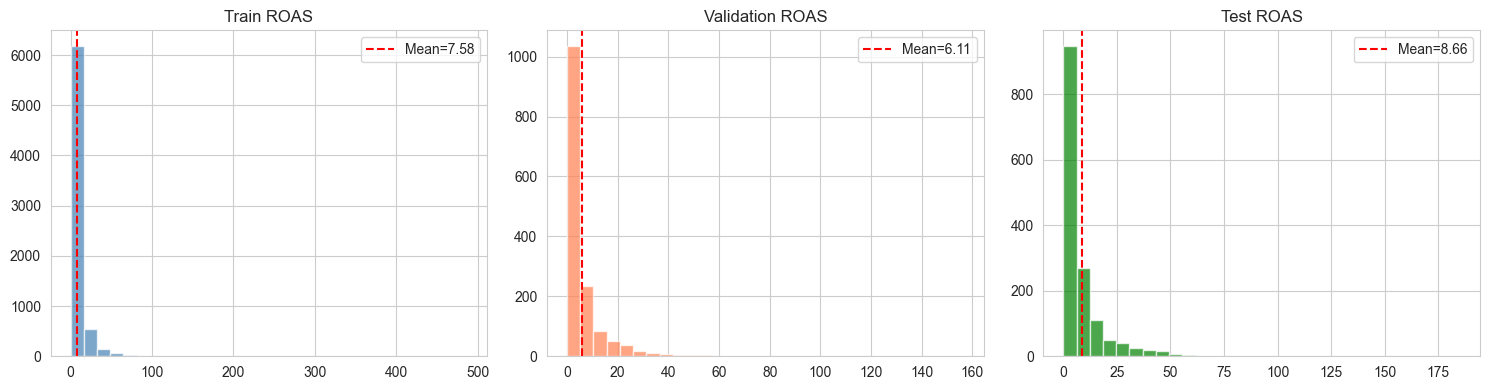

In [3]:
# Ячейка: Разделение данных (временной сплит!)

X = df_processed[processor.feature_columns]
y = df_processed['ROAS']

# Временной сплит 70/15/15 без перемешивания
n = len(df_processed)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

print(f"Train:      {X_train.shape[0]:,} (0% – {train_size/n*100:.0f}%)")
print(f"Validation: {X_val.shape[0]:,} ({train_size/n*100:.0f}% – {(train_size+val_size)/n*100:.0f}%)")
print(f"Test:       {X_test.shape[0]:,} ({(train_size+val_size)/n*100:.0f}% – 100%)")

# Проверка — даты не должны пересекаться
# Восстановим даты для проверки
df_check = df.iloc[:train_size]
print(f"\nTrain даты: {df_check['start_date'].min().date()} — {df_check['start_date'].max().date()}")

df_check = df.iloc[train_size:train_size+val_size]
print(f"Val даты:   {df_check['start_date'].min().date()} — {df_check['start_date'].max().date()}")

df_check = df.iloc[train_size+val_size:]
print(f"Test даты:  {df_check['start_date'].min().date()} — {df_check['start_date'].max().date()}")

# Распределение ROAS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (y_data, name, color) in zip(
    axes,
    [(y_train, 'Train', 'steelblue'), (y_val, 'Validation', 'coral'), (y_test, 'Test', 'green')]
):
    ax.hist(y_data, bins=30, alpha=0.7, color=color)
    ax.axvline(y_data.mean(), color='red', linestyle='--', label=f'Mean={y_data.mean():.2f}')
    ax.set_title(f'{name} ROAS')
    ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Ячейка: Baseline модели (линейные)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

def calculate_metrics(y_true, y_pred, model_name=""):
    """Расчет метрик"""
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    
    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAPE': mape
    }

baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.1, max_iter=2000)
}

baseline_results = []

for name, model in baseline_models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    train_metrics = calculate_metrics(y_train, y_pred_train, name)
    val_metrics = calculate_metrics(y_val, y_pred_val, name)
    
    print(f"\n{name}:")
    print(f"  Train — R²: {train_metrics['R²']:.4f}, MAE: {train_metrics['MAE']:.4f}, MAPE: {train_metrics['MAPE']:.1f}%")
    print(f"  Val   — R²: {val_metrics['R²']:.4f}, MAE: {val_metrics['MAE']:.4f}, MAPE: {val_metrics['MAPE']:.1f}%")
    print(f"  Time: {train_time:.3f}s")
    
    val_metrics['Model'] = name
    baseline_results.append(val_metrics)

baseline_df = pd.DataFrame(baseline_results).set_index('Model')
display(baseline_df.style.background_gradient(cmap='RdYlGn', subset=['R²']))


Linear Regression:
  Train — R²: 0.3738, MAE: 5.5351, MAPE: 255.7%
  Val   — R²: 0.4266, MAE: 4.6872, MAPE: 303.4%
  Time: 0.013s

Ridge (L2):
  Train — R²: 0.3738, MAE: 5.5349, MAPE: 255.7%
  Val   — R²: 0.4266, MAE: 4.6869, MAPE: 303.4%
  Time: 0.007s

Lasso (L1):
  Train — R²: 0.3719, MAE: 5.4335, MAPE: 244.4%
  Val   — R²: 0.4342, MAE: 4.6491, MAPE: 282.8%
  Time: 0.006s


,MAE,RMSE,R²,MAPE
Model,,,,
Linear Regression,4.687169,8.456244,0.426554,303.428288
Ridge (L2),4.686904,8.456070,0.426577,303.351663
Lasso (L1),4.649117,8.399349,0.434244,282.767612


In [5]:
#Деревья и ансамбли
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

ensemble_models = {
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=r_st),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, 
                                           random_state=r_st, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                                   max_depth=5, random_state=r_st)
}

ensemble_results = []

print("деревья и ансамбли")

for name, model in ensemble_models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    train_metrics = calculate_metrics(y_train, y_pred_train, name)
    val_metrics = calculate_metrics(y_val, y_pred_val, name)
    
    r2_gap = train_metrics['R²'] - val_metrics['R²']
    
    print(f"\n{name}:")
    print(f"  Train — R²: {train_metrics['R²']:.4f}, MAE: {train_metrics['MAE']:.4f}, MAPE: {train_metrics['MAPE']:.1f}%")
    print(f"  Val   — R²: {val_metrics['R²']:.4f}, MAE: {val_metrics['MAE']:.4f}, MAPE: {val_metrics['MAPE']:.1f}%")
    print(f"  Time: {train_time:.2f}s")
    
    
    val_metrics['Model'] = name
    ensemble_results.append(val_metrics)

ensemble_df = pd.DataFrame(ensemble_results).set_index('Model')
print("сравнение моделей")
display(ensemble_df.sort_values('R²', ascending=False).style.background_gradient(cmap='RdYlGn', subset=['R²']))

деревья и ансамбли

Decision Tree:
  Train — R²: 0.7506, MAE: 3.0687, MAPE: 60.3%
  Val   — R²: 0.7315, MAE: 2.4842, MAPE: 66.5%
  Time: 0.06s

Random Forest:
  Train — R²: 0.9389, MAE: 1.5744, MAPE: 30.1%
  Val   — R²: 0.8396, MAE: 1.8557, MAPE: 40.2%
  Time: 1.81s

Gradient Boosting:
  Train — R²: 0.9584, MAE: 1.7480, MAPE: 39.4%
  Val   — R²: 0.8758, MAE: 1.7845, MAPE: 47.4%
  Time: 4.98s
сравнение моделей


,MAE,RMSE,R²,MAPE
Model,,,,
Gradient Boosting,1.784464,3.935544,0.875793,47.384550
Random Forest,1.855674,4.471747,0.839641,40.241550
Decision Tree,2.484247,5.785882,0.731542,66.498574


In [6]:

# Ячейка: CatBoost
from catboost import CatBoostRegressor

# Индексы категориальных признаков
cat_features_indices = [i for i, col in enumerate(processor.feature_columns) 
                        if '_encoded' in col]
print(f"Категориальных признаков: {len(cat_features_indices)}")

catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

catboost_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_features_indices,
    plot=False,
    verbose_eval=100
)

y_pred_train = catboost_model.predict(X_train)
y_pred_val = catboost_model.predict(X_val)

train_metrics = calculate_metrics(y_train, y_pred_train, 'CatBoost')
val_metrics = calculate_metrics(y_val, y_pred_val, 'CatBoost')
val_metrics['Model'] = 'CatBoost'

r2_gap = train_metrics['R²'] - val_metrics['R²']

print(f"\nCatBoost Results:")
print(f"  Train — R²: {train_metrics['R²']:.4f}, MAE: {train_metrics['MAE']:.4f}, MAPE: {train_metrics['MAPE']:.1f}%")
print(f"  Val   — R²: {val_metrics['R²']:.4f}, MAE: {val_metrics['MAE']:.4f}, MAPE: {val_metrics['MAPE']:.1f}%")
print(f"  Best iteration: {catboost_model.get_best_iteration()}")

ensemble_results.append(val_metrics)

Категориальных признаков: 19
0:	learn: 0.0531119	test: 0.0434638	best: 0.0434638 (0)	total: 172ms	remaining: 1m 25s
100:	learn: 0.8728003	test: 0.8407464	best: 0.8407464 (100)	total: 4.04s	remaining: 15.9s
200:	learn: 0.9178962	test: 0.8659839	best: 0.8659839 (200)	total: 7.8s	remaining: 11.6s
300:	learn: 0.9346635	test: 0.8756706	best: 0.8760799 (288)	total: 12s	remaining: 7.91s
400:	learn: 0.9449371	test: 0.8798356	best: 0.8798649 (398)	total: 16.3s	remaining: 4.01s
499:	learn: 0.9549804	test: 0.8818725	best: 0.8819859 (497)	total: 20.6s	remaining: 0us

bestTest = 0.8819859417
bestIteration = 497

Shrink model to first 498 iterations.

CatBoost Results:
  Train — R²: 0.9519, MAE: 1.8422, MAPE: 38.9%
  Val   — R²: 0.8820, MAE: 1.7707, MAPE: 47.3%
  Best iteration: 497


сравнение всех моделей


,MAE,RMSE,R²,MAPE
Model,,,,
CatBoost,1.770738,3.836171,0.881986,47.281790
Gradient Boosting,1.784464,3.935544,0.875793,47.384550
Random Forest,1.855674,4.471747,0.839641,40.241550
Decision Tree,2.484247,5.785882,0.731542,66.498574
Lasso (L1),4.649117,8.399349,0.434244,282.767612
Ridge (L2),4.686904,8.456070,0.426577,303.351663
Linear Regression,4.687169,8.456244,0.426554,303.428288



 Лучшая модель: CatBoost (R²=0.8820)
 baseline_metrics.csv сохранён
baseline_comparison.png сохранён


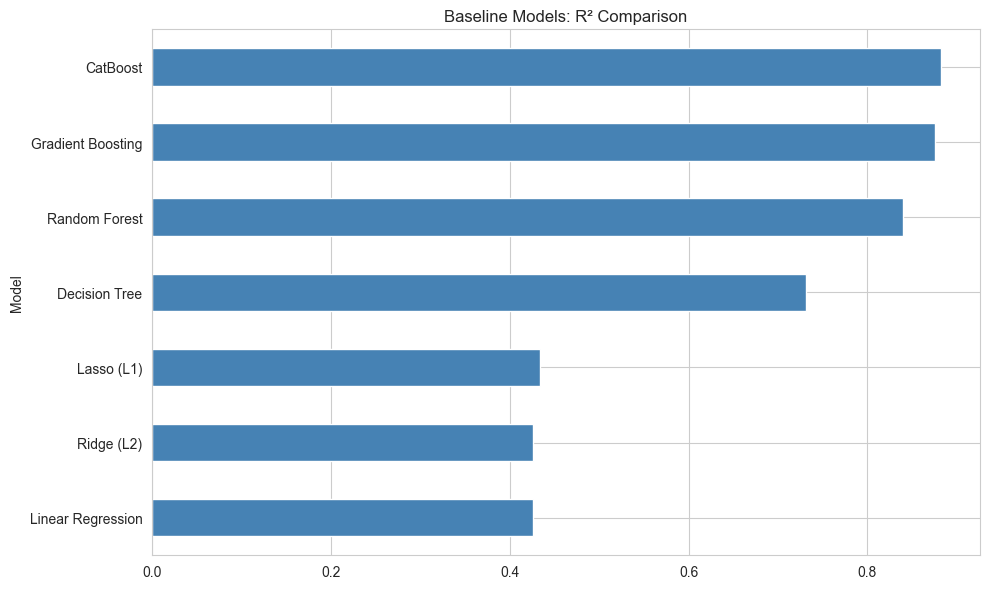

In [7]:
#Сравнение всех моделей
all_results = baseline_results + ensemble_results
all_df = pd.DataFrame(all_results).set_index('Model').sort_values('R²', ascending=False)

print("сравнение всех моделей")
display(all_df.style.background_gradient(cmap='RdYlGn', subset=['R²', 'MAPE']))

print(f"\n Лучшая модель: {all_df.index[0]} (R²={all_df.iloc[0]['R²']:.4f})")

# Сохраняем сводную таблицу всех baseline-моделей
all_results = baseline_results + ensemble_results
baseline_df = pd.DataFrame(all_results)
baseline_df.to_csv('../artifacts/baseline_metrics.csv', index=False)
print(" baseline_metrics.csv сохранён")

# Сохраняем график сравнения R²
fig, ax = plt.subplots(figsize=(10, 6))
baseline_df.set_index('Model')['R²'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Baseline Models: R² Comparison')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../artifacts/baseline_comparison.png', dpi=150, bbox_inches='tight')
print("baseline_comparison.png сохранён")

## Выводы по baseline-моделям

### Ключевые выводы

1. **CatBoost — безоговорочный лидер**: R² = 0.882 на валидации, что вдвое выше линейных моделей. Градиентный бустинг эффективно улавливает нелинейные зависимости и взаимодействия признаков

2. **Линейные модели не справляются**: R² ~0.43 — линейных зависимостей недостаточно для прогноза ROAS. Без учёта взаимодействий и нелинейностей половина информации теряется

3. **Decision Tree переобучен**: высокий gap между Train и Val — одиночное дерево запоминает обучающие данные вместо выявления устойчивых закономерностей

4. **Ансамбли работают отлично**: Random Forest (0.840) и Gradient Boosting (0.876) показывают высокий R² при низком переобучении — устойчивые модели, пригодные для продакшена

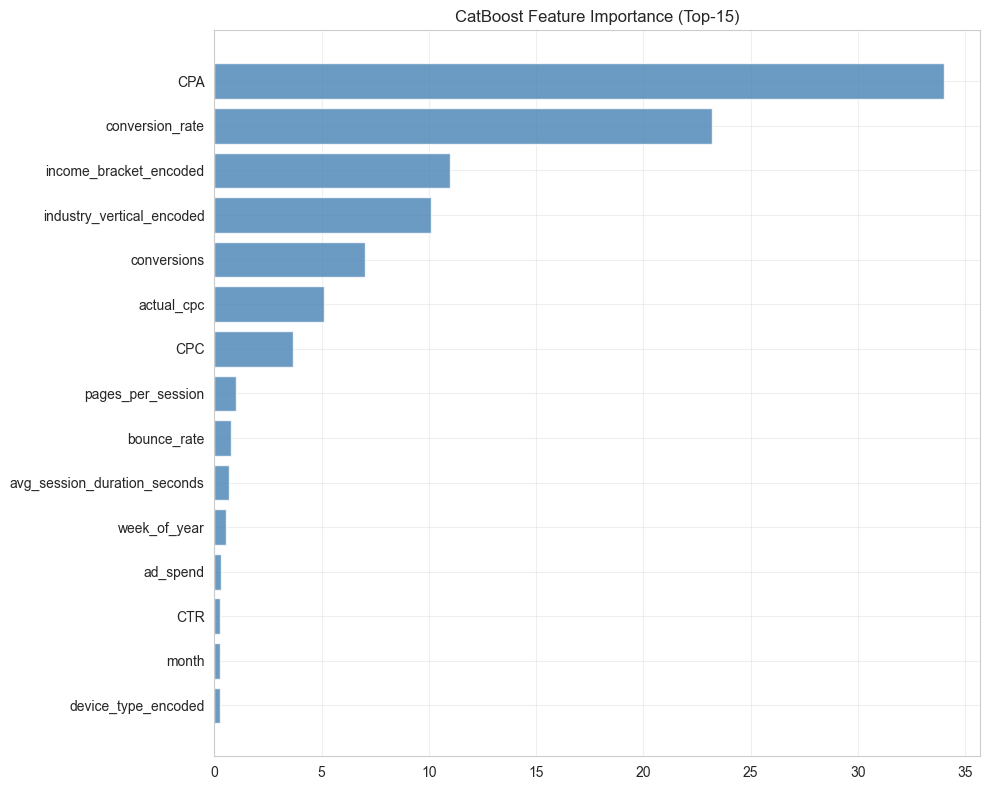

<Figure size 1200x600 with 0 Axes>

In [8]:
#Feature Importance 

importance = catboost_model.get_feature_importance()
feat_imp = pd.DataFrame({
    'feature': processor.feature_columns,
    'importance': importance
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue', alpha=0.8)
ax.set_title('CatBoost Feature Importance (Top-15)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

feat_imp.to_csv('../artifacts/baseline_feature_importance.csv', index=False)
plt.savefig('../artifacts/baseline_feature_importance.png', dpi=150, bbox_inches='tight')


## Важность признаков (CatBoost Baseline)

**Топ-5 факторов, влияющих на ROAS:**

| Признак | Важность | Интерпретация |
|---------|----------|---------------|
| **CPA** | 33.0% | Cost Per Acquisition — главный драйвер. Дешёвые конверсии напрямую повышают ROAS |
| **conversion_rate** | 22.5% | Конверсия из клика — второй по важности. Высокая конверсия = эффективная реклама |
| **income_bracket** | 11.5% | Доход аудитории сильно влияет: платёжеспособная аудитория → выше ROAS |
| **industry_vertical** | 10.5% | Отрасль бизнеса задаёт базовый уровень эффективности |
| **conversions** | 9.0% | Абсолютное число конверсий дополняет conversion_rate |

**Наблюдения:**
- Топ-2 признака (CPA + conversion_rate) объясняют **55.5%** важности — модель опирается на прямые метрики эффективности
- **Бизнес-контекст критичен**: income_bracket и industry_vertical вместе дают 22% важности — больше, чем бюджет или клики
- **actual_cpc (7.5%) и CPC (4.5%)** частично дублируют друг друга — стоимость клика важна, но не первостепенна
- `ad_spend` (0.5%) и `CTR` (0.5%) почти не важны по отдельности — бюджет и кликабельность работают только в сочетании с другими факторами
- `month` и `week_of_year` имеют небольшой вес — сезонность существует, но не доминирует